In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import json as js

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['figure.dpi'] = 150  # ou 200

In [6]:
with open("DATA_Cluster/ErrorAgainstTaubeta10.json", "r") as file:
    dic = js.load(file)

beta_list = dic["beta list"]
tau_list = dic["tau list"]

In [ ]:
def error(y_data, exact_data):
    if exact_data == 0:
        return y_data
    error_value = (y_data-exact_data)/exact_data
    return error_value

from scipy.integrate import quad

def exact_energy_XY(beta, h=0.0, gamma=0.0):
    def epsilon(k, h, gamma):
        return np.sqrt((np.cos(k) - h)**2 + (gamma * np.sin(k))**2)
    
    def integrand(k):
        e = epsilon(k, h, gamma)
        return e * np.tanh(0.5 * beta * e) / (2 * np.pi)
    
    val, _ = quad(integrand, -np.pi, np.pi, epsrel=1e-9)
    return -val / 2

exact_energy_list = np.array([exact_energy_XY(beta) for beta in beta_list])

In [ ]:
mean_energy_site = np.mean(dic["energy"], axis=2)
mean_magnet_site = np.mean(dic["magnet"], axis=2)

print("shape average energy over sites", np.shape(mean_energy_site))
print("shape average magnet over sites", np.shape(mean_magnet_site))
print("number of beta = ", len(beta_list))
print("number of tau = ", len(tau_list))

dist_tau_energy = np.linalg.norm(mean_energy_site - exact_energy_list[None ,:], axis=1)

print("shape de erreur en fonction de tau", np.shape(dist_tau_energy))

shape average energy over sites (5, 101)
shape average magnet over sites (5, 101)
number of beta =  101
number of tau =  5
shape de erreur en fonction de tau (5,)


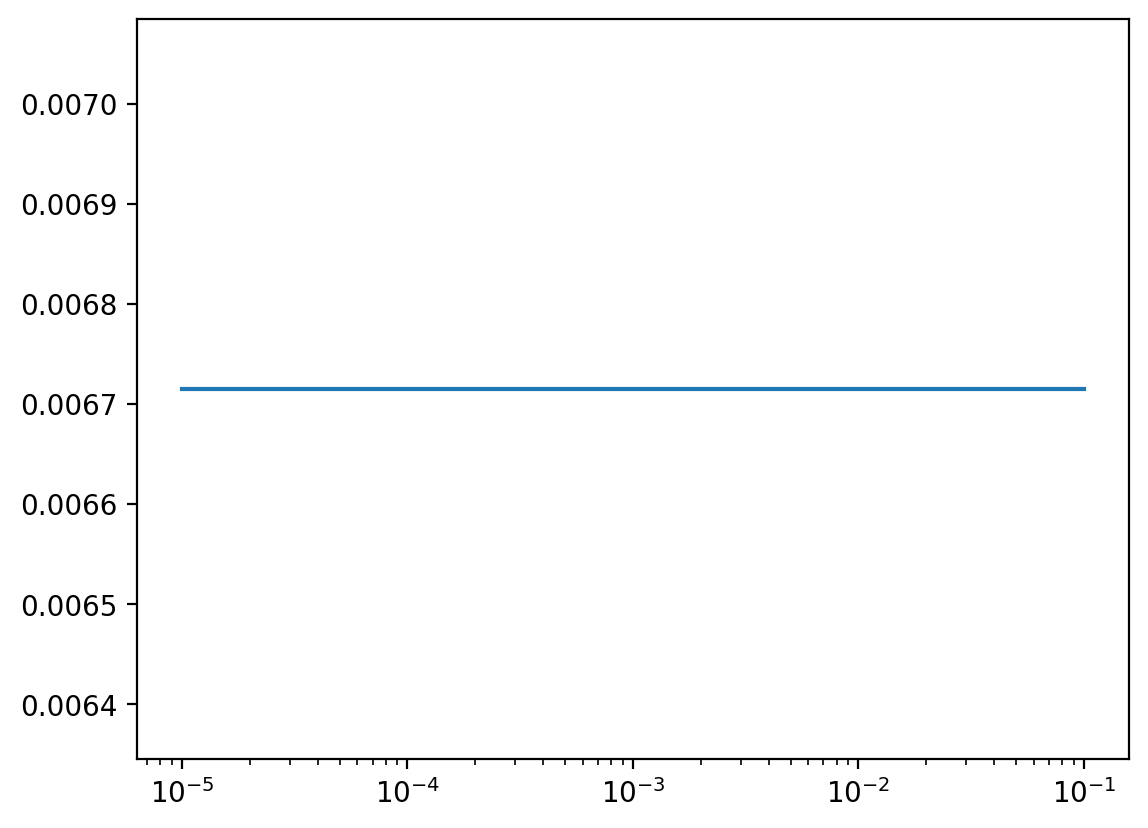

In [ ]:
fig, ax = plt.subplots()
ax.semilogx(tau_list, dist_tau_energy)
plt.show()

101


array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True])

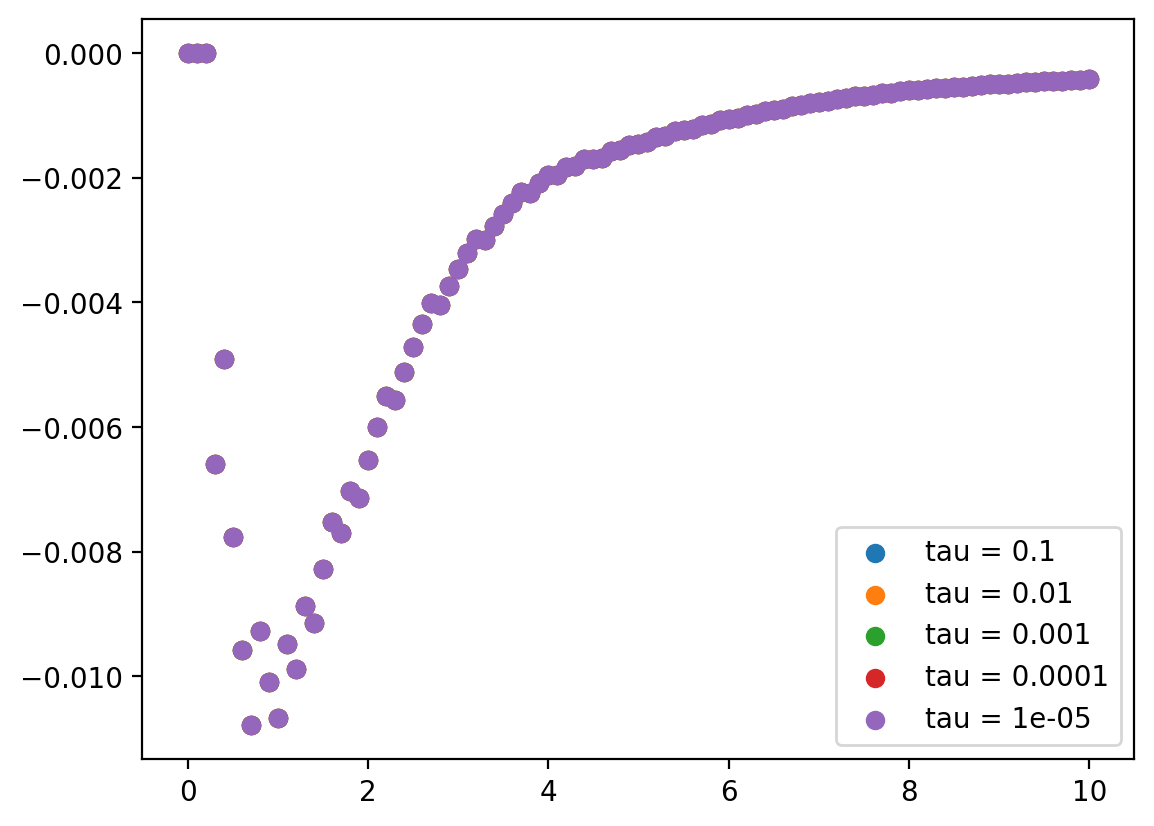

In [ ]:
error_beta_tau = {}

for i in range(len(tau_list)):
    error_beta_tau[f"tau = {tau_list[i]}"] = np.array([error(mean_energy_site[i, :][k], exact_energy_list[k]) for k in range(len(exact_energy_list))])

error_beta_tau
print(len(error_beta_tau["tau = 0.1"]))

fig, ax = plt.subplots()
for i in range(len(tau_list)):
    ax.scatter(beta_list, error_beta_tau[f"tau = {tau_list[i]}"], label = f"tau = {tau_list[i]}")
plt.legend()
plt.show

error_beta_tau["tau = 0.1"] == error_beta_tau["tau = 0.01"]
